## Visualization exercise
```In the following exercise you are to practice simple data scientist tasks. Mainly, you learn about a few common, useful but slightly advanced visualization methods. You will work with the Chicago Crime data, which concerns crimes in Chicago. You will be asked to draw some of this data features.```

```~Ittai Haran```

In [1]:
import seaborn as sns
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
%matplotlib inline

```Start with loading the data.
link for the data: https://drive.google.com/open?id=1oy7hnl3u8IYt7U69kOqATwbooEXSUzrm```

In [3]:
df = pd.read_csv('Crimes_-_2001_to_present.csv')

```What are the types of the columns? Which columns contain numbers? Which contain nans?
Among the categorical columns that contain nans, how many distinct values are there?```

In [4]:
pd.set_option('display.max_columns', None)

df.head()

,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
0,4647369,HM155213,01/31/2006 12:13:05 PM,066XX N BOSWORTH AVE,1811,NARCOTICS,POSS: CANNABIS 30GMS OR LESS,"SCHOOL, PUBLIC, BUILDING",True,False,2432,24.0,40.0,1.0,18,1164737.0,1944193.0,2006,04/15/2016 08:55:02 AM,42.002478,-87.669297,"(42.002478396, -87.66929687)"
1,4647370,HM245080,03/21/2006 07:00:00 PM,062XX S WESTERN AVE,1330,CRIMINAL TRESPASS,TO LAND,PARKING LOT/GARAGE(NON.RESID.),True,False,825,8.0,15.0,66.0,26,1161441.0,1863309.0,2006,04/15/2016 08:55:02 AM,41.780595,-87.683676,"(41.780595495, -87.68367553)"
2,4647372,HM171175,02/09/2006 01:44:41 AM,058XX S SHIELDS AVE,1811,NARCOTICS,POSS: CANNABIS 30GMS OR LESS,STREET,True,False,711,7.0,20.0,68.0,18,1174958.0,1866097.0,2006,04/15/2016 08:55:02 AM,41.787955,-87.634037,"(41.787955143, -87.634036744)"
3,4647373,HM244805,03/21/2006 04:45:00 PM,011XX N SPAULDING AVE,0810,THEFT,OVER $500,CHURCH/SYNAGOGUE/PLACE OF WORSHIP,False,False,1121,11.0,26.0,23.0,06,1154100.0,1907414.0,2006,04/15/2016 08:55:02 AM,41.901774,-87.709415,"(41.901774026, -87.709414574)"
4,4647374,HM245851,03/21/2006 10:00:00 PM,080XX S DOBSON AVE,0820,THEFT,$500 AND UNDER,STREET,False,False,631,6.0,8.0,44.0,06,1184622.0,1851863.0,2006,04/15/2016 08:55:02 AM,41.748675,-87.599049,"(41.748674558, -87.599048654)"


In [4]:
df.describe()

,ID,Beat,District,Ward,Community Area,X Coordinate,Y Coordinate,Year,Latitude,Longitude
count,6.492089e+06,6.492089e+06,6.492040e+06,5.877236e+06,5.876060e+06,6.404618e+06,6.404618e+06,6.492089e+06,6.404618e+06,6.404618e+06
mean,6.025035e+06,1.193889e+03,1.130696e+01,2.264317e+01,3.762995e+01,1.164491e+06,1.885668e+06,2.007944e+03,4.184187e+01,-8.767190e+01
std,2.920630e+06,7.035835e+02,6.945100e+00,1.381767e+01,2.153411e+01,1.736213e+04,3.297943e+04,4.724579e+00,9.076079e-02,6.276446e-02
min,6.340000e+02,1.110000e+02,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.001000e+03,3.661945e+01,-9.168657e+01
25%,3.346938e+06,6.230000e+02,6.000000e+00,1.000000e+01,2.300000e+01,1.152923e+06,1.859170e+06,2.004000e+03,4.176888e+01,-8.771391e+01
50%,5.992097e+06,1.111000e+03,1.000000e+01,2.200000e+01,3.200000e+01,1.165941e+06,1.890350e+06,2.007000e+03,4.185487e+01,-8.766633e+01
75%,8.545908e+06,1.731000e+03,1.700000e+01,3.400000e+01,5.800000e+01,1.176352e+06,1.909339e+06,2.012000e+03,4.190692e+01,-8.762845e+01
max,1.117180e+07,2.535000e+03,3.100000e+01,5.000000e+01,7.700000e+01,1.205119e+06,1.951622e+06,2.017000e+03,4.202291e+01,-8.752453e+01


In [6]:
columns_with_nan = df.isnull().any()
cats_columns = df.select_dtypes(include=['object']).columns

categorical_columns_with_nans = [col for col in cats_columns if columns_with_nan[col]]

x = {col: df[col].nunique() for col in categorical_columns_with_nans}

x



{'Case Number': 6491706, 'Location Description': 173, 'Location': 850795}

```Plot the distribution of each of the numeric features (hist: plt.hist, or pd.DataFrame.hist).
Also, If there are columns that have missing values, but also have less than 200 different values, plot their histogram ( maybe by using sns.categorical.countplot).```

In [7]:
columns_with_nan_and_less_than_200_uniques = [col for col in df.columns if df[col].isnull().any() and df[col].nunique() < 200]
columns_with_nan_and_less_than_200_uniques

['Location Description', 'District', 'Ward', 'Community Area']

C:\Users\user\AppData\Local\Temp\ipykernel_3696\850428454.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette="viridis")


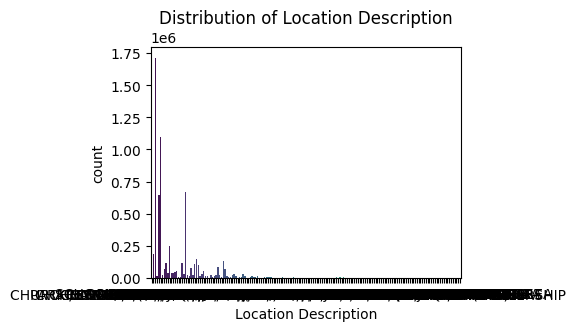

C:\Users\user\AppData\Local\Temp\ipykernel_3696\850428454.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette="viridis")


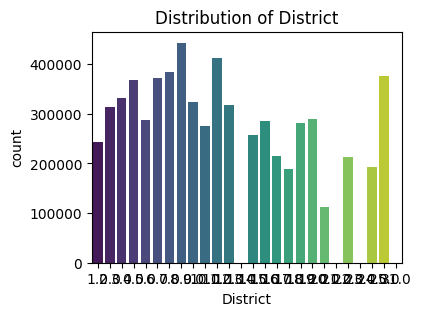

C:\Users\user\AppData\Local\Temp\ipykernel_3696\850428454.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette="viridis")


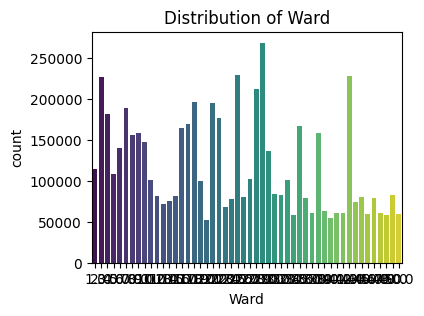

C:\Users\user\AppData\Local\Temp\ipykernel_3696\850428454.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette="viridis")


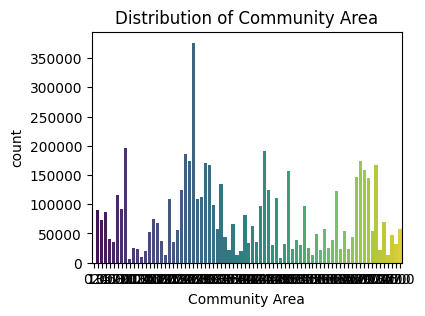

In [8]:

for col in columns_with_nan_and_less_than_200_uniques:
    plt.figure(figsize=(4, 3))
    sns.countplot(x=df[col], palette="viridis")
    plt.title(f'Distribution of {col}')
    plt.show()

```Now plot the number of crimes in Chicago per month, and the number of arrests per month. Use df.plot.```

C:\Users\user\AppData\Local\Temp\ipykernel_1152\1488729363.py:1: FutureWarning: 'm' is deprecated and will be removed in a future version, please use 'ME' instead.
  df.set_index('Date').resample('1m').agg({'ID':len, 'Arrest':sum}).plot()
C:\Users\user\AppData\Local\Temp\ipykernel_1152\1488729363.py:1: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  df.set_index('Date').resample('1m').agg({'ID':len, 'Arrest':sum}).plot()


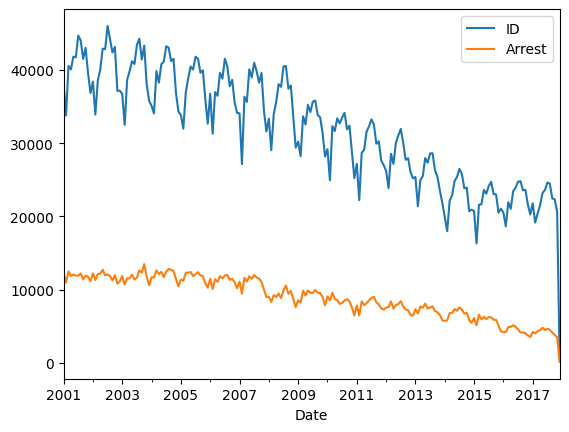

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date').resample('1m').agg({'ID':len, 'Arrest':sum}).plot()
plt.show()

```Do the same for weeks rather than months. Use df.resample.```

C:\Users\user\AppData\Local\Temp\ipykernel_1152\1628273823.py:1: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  df.set_index('Date').resample('1W').agg({'ID':len, 'Arrest':sum}).plot()


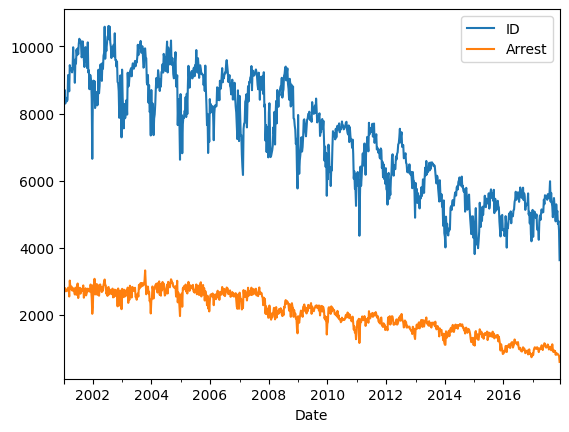

In [25]:
df.set_index('Date').resample('1W').agg({'ID':len, 'Arrest':sum}).plot()

plt.show()

```Lets look at the distribution of 'Ward', for Arrest=True and for Arrest=False. Use sns.violinplot.```

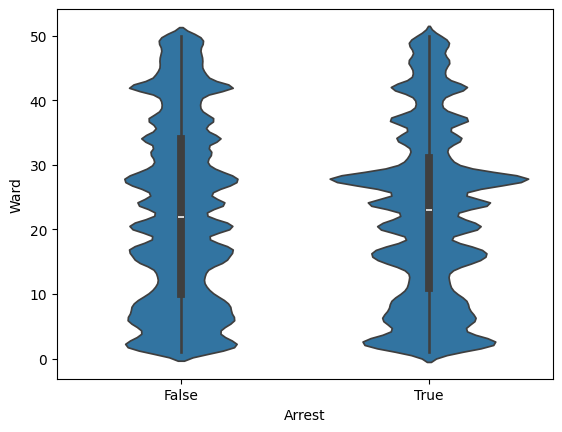

In [10]:
sns.violinplot(data = df, x = 'Arrest', y = 'Ward')
plt.show()
# boxplot with dencity

```Plot in the same graph, for each Primary Type, the number of crimes of this type, for each month. Do it using df.pivot_table.```

C:\Users\user\AppData\Local\Temp\ipykernel_1152\1518032213.py:1: FutureWarning: 'm' is deprecated and will be removed in a future version, please use 'M' instead.
  df['month'] = df['Date'].dt.to_period('m')


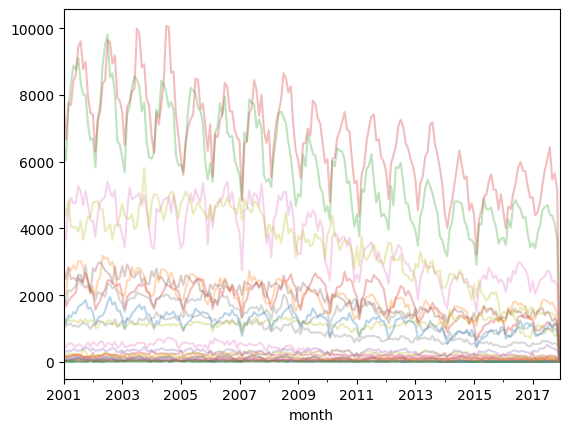

In [27]:
df['month'] = df['Date'].dt.to_period('m')
df[['month', 'Primary Type']].dropna().pivot_table(index = 'month', columns = ['Primary Type'], aggfunc = len).plot(legend=False, alpha = 0.3)
plt.show()

```Let's focus on the features 'X Coordinate', 'Y Coordinate'. What is the relation between them? Use sns.pairplot and sns.jointplot to answer this question. You might want to get rid of the missing values before you act. Can you find another problem preventing you from understanding the relations between the features? What is it and how can you get rid of it?```

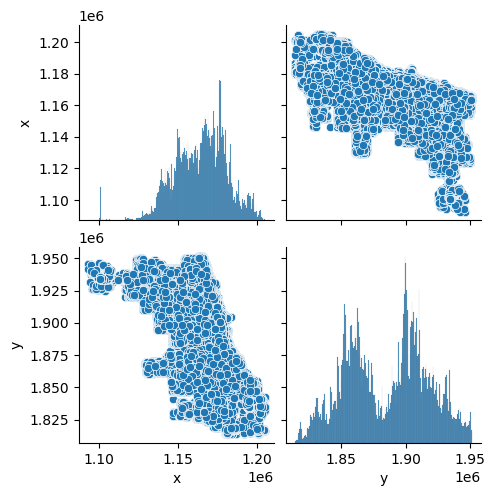

TypeError: jointplot() takes from 0 to 1 positional arguments but 3 positional arguments (and 1 keyword-only argument) were given

In [11]:
df_x_y = df.set_index('Date')[['X Coordinate', 'Y Coordinate']].dropna()
df_x_y.columns = ['x', 'y']
df_x_y = df_x_y[np.sum(df_x_y == 0, axis = 1) == 0]

sns.pairplot(df_x_y)
plt.show()
sns.jointplot('x', 'y', df_x_y, kind = 'hex')
plt.colorbar()
plt.show()

```Split the map into 25 districts, and plot the number of crime incidents in each one of them, per month. First rotate the map so it will be more 'square-like' (Hint: by a linear transformation).```

C:\Users\user\AppData\Local\Temp\ipykernel_3696\731575673.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  x_y_pcaed_cliped.index = pd.to_datetime(x_y_pcaed_cliped.index)  # Convert to DateTimeIndex


<Axes: xlabel='month'>

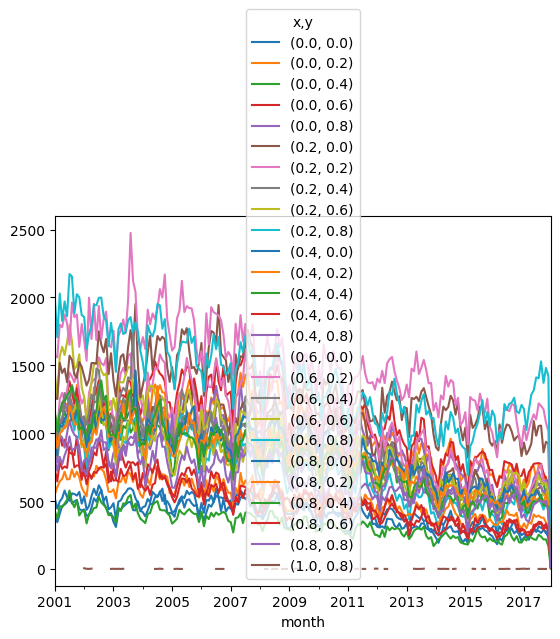

In [13]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
pca = PCA(2)
x_y_pcaed = pd.DataFrame(pca.fit_transform(df_x_y.dropna()), columns = ['x', 'y'], index = df_x_y.index)

x_y_pcaed_percentiles = pd.DataFrame(x_y_pcaed.rank().values/float(len(x_y_pcaed)), columns = ['x', 'y'], index = x_y_pcaed.index)
x_y_pcaed_cliped = x_y_pcaed[((x_y_pcaed_percentiles['x']>0.1).astype(int)+(x_y_pcaed_percentiles['y']>0.1).astype(int)+
                              (x_y_pcaed_percentiles['x']<0.9).astype(int)+(x_y_pcaed_percentiles['y']<0.9).astype(int)) == 4]
x_y_pcaed_cliped = pd.DataFrame((MinMaxScaler().fit_transform(x_y_pcaed_cliped)*5).astype(int)/5.0, columns = ['x', 'y'],
                               index = x_y_pcaed_cliped.index)
x_y_pcaed_cliped.index = pd.to_datetime(x_y_pcaed_cliped.index)  # Convert to DateTimeIndex
x_y_pcaed_cliped['month'] = x_y_pcaed_cliped.index.to_period('M')  # Convert to monthly period
x_y_pcaed_cliped.pivot_table(index = 'month', columns = ['x', 'y'], aggfunc=len).plot()



```Bonus: create a word cloud from the words you can find in the 'Description' field.```

In [32]:
from wordcloud import WordCloud

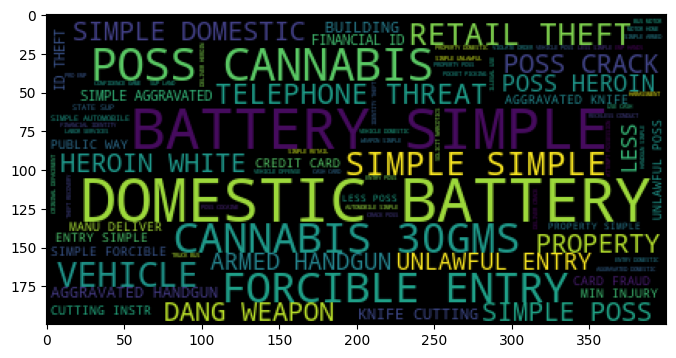

In [33]:
string_of_descs = ' '.join(list(df['Description']))
wordcloud = WordCloud().generate(string_of_descs)

fig = plt.figure(1, figsize=(8,10))
plt.imshow(wordcloud)
plt.show()